
<div dir=ltr align=center>

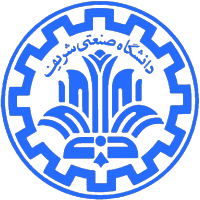

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Virtual Autoencoder<br>
<font color=696880 size=4>
Prepared by Group 38

____

In [ ]:
# Group Members
Name = 'Farid Mahmoudzadeh'
Studen_ID = '401106493'

# Setup

## Imports

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import Counter

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

## Reproducibility

In [2]:
# Set global seed for reproducibility
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Provide Data + EDA

## Data Provision

In [3]:
# ==============================
# Download / Load Dataset
# ==============================

data_dir = "./data"

# Preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                 # Convert to tensor [0,1]
    transforms.Normalize((0.5,), (0.5,))   # Normalize to [-1, 1]
])

# Load full training set
full_train_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=True,
    download=True,
    transform=transform
)
# Train / Validation Split
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Load test set
test_dataset = datasets.FashionMNIST(
    root=data_dir,
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.5MB/s]


In [4]:
# Dataset Samples
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

# Image Shape
sample_image, sample_label = train_dataset[0]
print("Single image shape:", sample_image.shape)

Train samples: 54000
Validation samples: 6000
Test samples: 10000
Single image shape: torch.Size([1, 28, 28])


In [5]:
# ==============================
# DataLoaders
# ==============================

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 422
Validation batches: 47
Test batches: 79


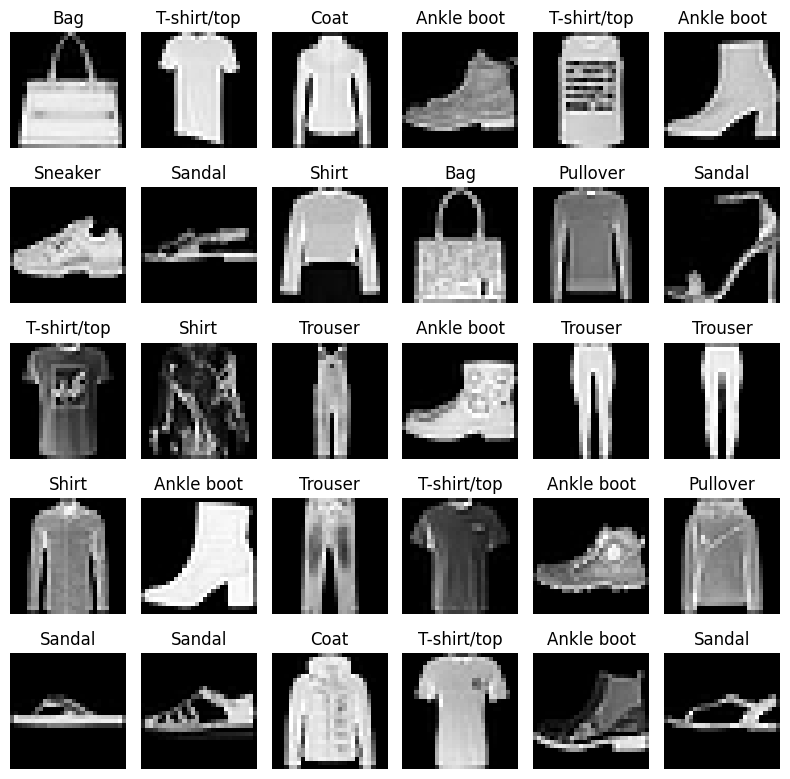

In [6]:
# ==============================
# Sanity Check (30 pictures)
# ==============================

class_names = full_train_dataset.classes

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(5, 6, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze() * 0.5 + 0.5  # Unnormalize for display
    ax.imshow(img.numpy(), cmap='gray')
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

## EDA

T-shirt/top: 5342
Trouser: 5389
Pullover: 5388
Dress: 5438
Coat: 5393
Sandal: 5387
Shirt: 5400
Sneaker: 5463
Bag: 5402
Ankle boot: 5398


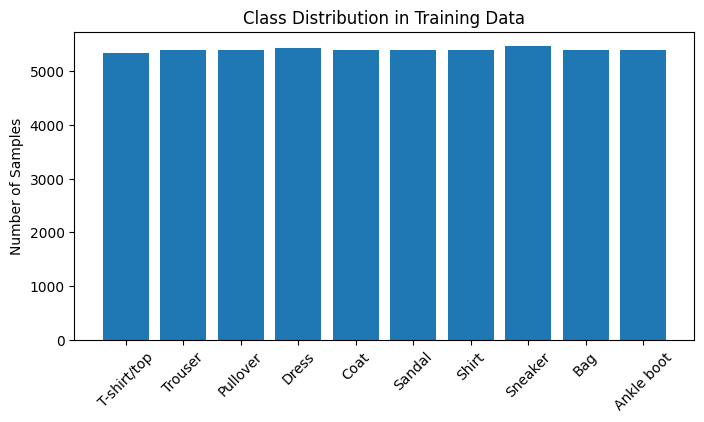

In [7]:
# ==============================
# Class Distribution
# ==============================

all_labels = []

for _, labels in train_dataset:
    all_labels.append(labels)

all_labels = np.array(all_labels)

unique, counts = np.unique(all_labels, return_counts=True)

for u, c in zip(unique, counts):
    print(f"{class_names[u]}: {c}")

plt.figure(figsize=(8,4))
plt.bar(unique, counts)
plt.xticks(unique, class_names, rotation=45)
plt.title("Class Distribution in Training Data")
plt.ylabel("Number of Samples")
plt.show()

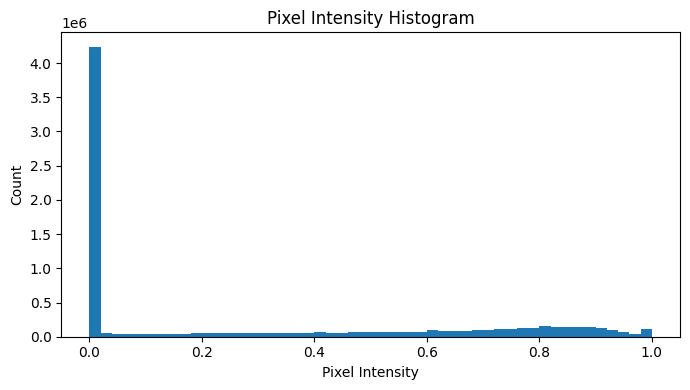

In [8]:
# ==============================
# Pixel Intensity Histogram
# ==============================

def sample_pixels(loader, max_batches=80):
    pixels = []
    used = 0
    for img, _ in loader:
        # flatten and unnormalize for intensity display
        pixels.append((img.view(-1)*0.5+0.5).cpu().numpy())
        used+=1
        if used >= max_batches:
            break
    return np.concatenate(pixels, axis=0)

pixels = sample_pixels(train_loader)
plt.figure(figsize=(7,4))
plt.hist(pixels, bins=50)
plt.title('Pixel Intensity Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

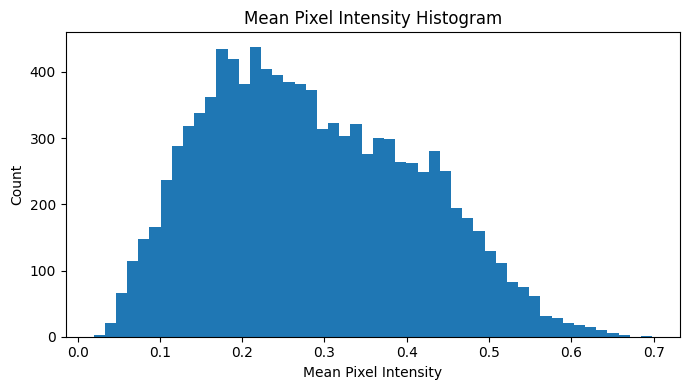

In [12]:
# ==============================
# Mean Pixel Intensity per Image
# ==============================

def sample_means(loader, max_batches=80):
    means = []
    used = 0
    for img, _ in loader:
        # Unnormalize for intensity display
        means.append((img.view(img.size(0), -1)*0.5+0.5).mean(dim=1).cpu().numpy())
        used+=1
        if used >= max_batches:
            break
    return np.concatenate(means, axis=0)

means = sample_means(train_loader)
plt.figure(figsize=(7,4))
plt.hist(means, bins=50)
plt.title('Mean Pixel Intensity Histogram')
plt.xlabel('Mean Pixel Intensity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()